
## This notebook is only for learning purpose(running code and get ideas about parameters)
---



In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, BatchNormalization
from keras.models import Sequential

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogvscat/train',
    labels = 'inferred',
    label_mode = 'int',
    image_size = (256,256),
    batch_size = 32
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogvscat/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 500 files belonging to 2 classes.
Found 50 files belonging to 2 classes.


### normalize

In [ ]:
def process(image,label):
  image = tf.cast(image/255. , tf.float32)
  return image, label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

## model

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape = (256,256,3)))
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [ ]:
history = model.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 752ms/step - accuracy: 0.4880 - loss: 0.7376 - val_accuracy: 0.5000 - val_loss: 0.6898
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 401ms/step - accuracy: 0.5920 - loss: 0.6798 - val_accuracy: 0.6200 - val_loss: 0.6597
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 526ms/step - accuracy: 0.6840 - loss: 0.6223 - val_accuracy: 0.5800 - val_loss: 0.6443
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 712ms/step - accuracy: 0.7300 - loss: 0.5243 - val_accuracy: 0.5800 - val_loss: 0.7000
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 855ms/step - accuracy: 0.8040 - loss: 0.4184 - val_accuracy: 0.5800 - val_loss: 0.8371
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 552ms/step - accuracy: 0.8940 - loss: 0.2653 - val_accuracy: 0.6400 - val_loss: 0.9165
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 545ms/step - accuracy: 0.9500 - loss: 0.1453 - val_accuracy: 0.6800 - val_loss: 0.9283
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 507ms/step - accuracy: 0.9820 - loss: 0.0722 - val_accurac

## Before doing batchnormalization and dropout layer

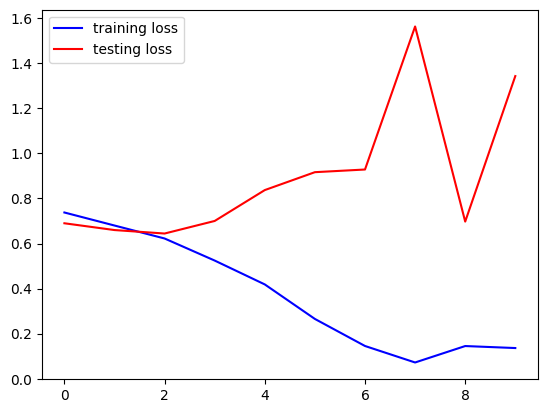

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color = 'blue', label = 'training loss')
plt.plot(history.history['val_loss'], color = 'red', label = 'testing loss')
plt.legend()
plt.show()

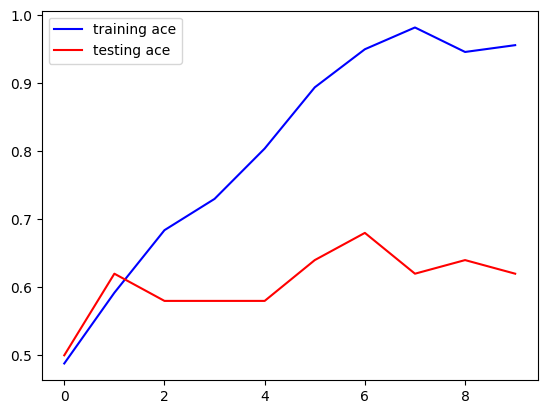

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'blue', label = 'training ace')
plt.plot(history.history['val_accuracy'], color = 'red', label = 'testing ace')
plt.legend()
plt.show()

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002), input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))


model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))



model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))



model.add(Flatten())

model.add(Dense(128, activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002)))
model.add(Dropout(0.4))

model.add(Dense(64, activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002)))
model.add(Dropout(0.4))

model.add(Dense(32, activation = 'relu', kernel_regularizer = keras.regularizers.l2(0.002)))
model.add(Dropout(0.4))

model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,784,321 (6.81 MB)

 Trainable params: 1,783,745 (6.80 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [ ]:
history = model.fit(train_ds, epochs = 15, validation_data = validation_ds)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 816ms/step - accuracy: 0.4940 - loss: 2.8900 - val_accuracy: 0.5400 - val_loss: 1.9469
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 478ms/step - accuracy: 0.5420 - loss: 2.6992 - val_accuracy: 0.5400 - val_loss: 2.0317
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 400ms/step - accuracy: 0.5340 - loss: 2.6537 - val_accuracy: 0.5400 - val_loss: 2.4615
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 482ms/step - accuracy: 0.5400 - loss: 2.6206 - val_accuracy: 0.5200 - val_loss: 2.0148
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 483ms/step - accuracy: 0.5420 - loss: 2.3396 - val_accuracy: 0.4600 - val_loss: 2.0314
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - accuracy: 0.5380 - loss: 2.2700 - val_accuracy: 0.5000 - val_loss: 2.1147
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 398ms/step - accuracy: 0.5940 - loss: 2.1051 - val_accuracy: 0.5000 - val_loss: 2.0771
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 481ms/step - accuracy: 0.5760 - loss: 2.1590 - val_accuracy:

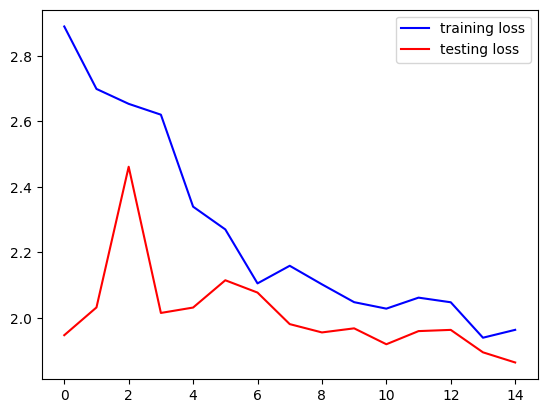

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color = 'blue', label = 'training loss')
plt.plot(history.history['val_loss'], color = 'red', label = 'testing loss')
plt.legend()
plt.show()

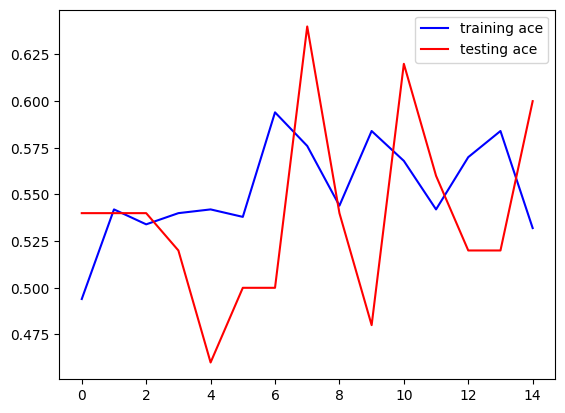

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'blue', label = 'training ace')
plt.plot(history.history['val_accuracy'], color = 'red', label = 'testing ace')
plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
img = cv2.imread('/content/dogvscat/test/0/274.jpg')

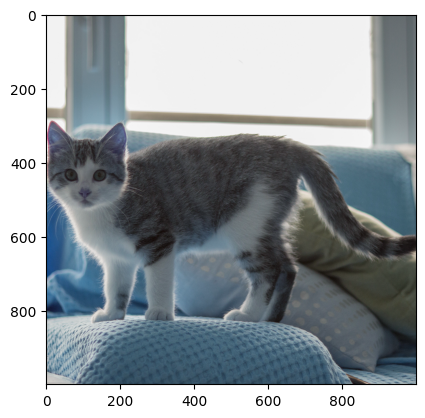

In [ ]:
plt.imshow(img)

In [ ]:
img.shape

(1000, 1000, 3)

In [ ]:
img = cv2.resize(img, (256, 256))
img = img.reshape(1, 256, 256, 3)


In [ ]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step


array([[1.]], dtype=float32)